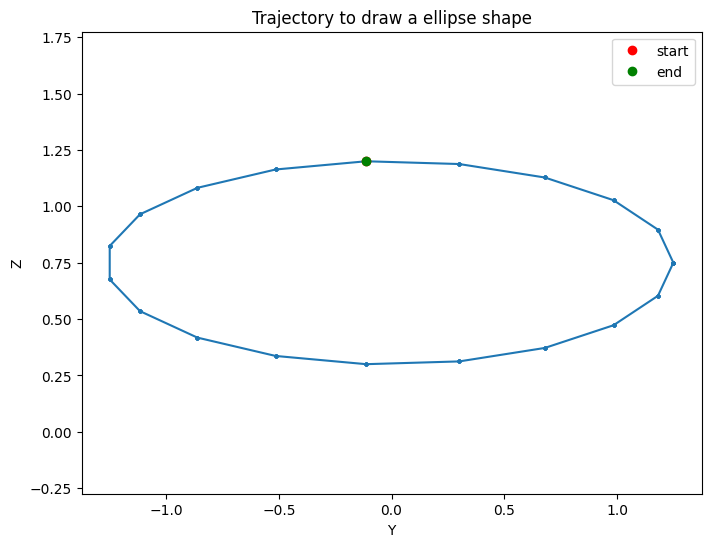

Shape of trajectory: (145, 3)


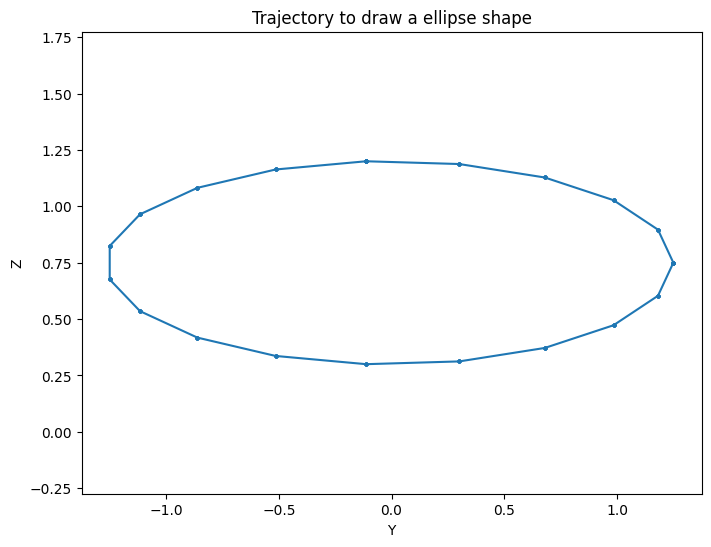

: 

In [ ]:
"Simple shape goal trajectory generator"

import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# select the shape
shape_type: str = "ellipse"  # Options: "heart", "ellipse", "infinity"

# fixed x-coordinate
x_fixed = 1.1

# parameter t (more points for smoother/slower trajectory)
t = np.linspace(0, 2 * np.pi, 20)

# depending on shape_type, define y and z
if shape_type == "heart":
    y = 16 * np.sin(t) ** 3
    z = 13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t)
elif shape_type == "ellipse":
    a = 1
    b = 0.5
    y = a * np.cos(t)
    z = b * np.sin(t)
elif shape_type == "infinity":
    y = np.sin(t)
    z = np.sin(2 * t)
else:
    raise ValueError(f"Unknown shape_type: {shape_type}")

# find the index where y is closest to zero
start_idx = np.argmin(np.abs(y))

# rotate y and z arrays so that y starts from the point closest to y=0
y = np.roll(y, -start_idx)
z = np.roll(z, -start_idx)

# normalize the coordinates and scale to desired ranges
desired_range_y = [-1.25, 1.25]
desired_range_z = [0.3, 1.2]

y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()
y_normalized = (y - y_min) / (y_max - y_min)
y_scaled = y_normalized * (desired_range_y[1] - desired_range_y[0]) + desired_range_y[0]
z_normalized = (z - z_min) / (z_max - z_min)
z_scaled = z_normalized * (desired_range_z[1] - desired_range_z[0]) + desired_range_z[0]

# ensure the trajectory is closed by appending the starting point at the end if necessary
if y_scaled[0] != y_scaled[-1] or z_scaled[0] != z_scaled[-1]:
    # append the starting point to the end
    y_scaled = np.append(y_scaled, y_scaled[0])
    z_scaled = np.append(z_scaled, z_scaled[0])
# repeat first point n times
repeat_first_point_times = 5
y_scaled = np.insert(y_scaled, 0, [y_scaled[0]] * (repeat_first_point_times - 1))
z_scaled = np.insert(z_scaled, 0, [z_scaled[0]] * (repeat_first_point_times - 1))

# repeat the last point n times
repeat_last_point_times = 5
y_scaled = np.append(y_scaled, [y_scaled[-1]] * (repeat_last_point_times - 1))
z_scaled = np.append(z_scaled, [z_scaled[-1]] * (repeat_last_point_times - 1))

# repeat each point (slows down trajectory)
repeat_times = 5
y_repeated = np.repeat(y_scaled, repeat_times)
z_repeated = np.repeat(z_scaled, repeat_times)

# fixed x-coordinate array
x_points = np.full_like(y_repeated, x_fixed)

# plot the trajectory
plt.figure(figsize=(8, 6))
plt.plot(y_repeated, z_repeated, '-o', markersize=2)
# highlight start and end points
plt.plot(y_repeated[0], z_repeated[0], 'ro', label='start')
plt.plot(y_repeated[-1], z_repeated[-1], 'go', label='end')
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.legend()
plt.show()

# save trajectory as array
trajectory = np.column_stack((x_points, y_repeated, z_repeated))
print("Shape of trajectory:", trajectory.shape)
dir_name = f"goal_traj/{shape_type}_v0_goal_trajectory.pkl"
# if it exists, append version
if os.path.exists(dir_name):
    version = 1
    while os.path.exists(dir_name):
        version += 1
        dir_name = f"goal_traj/{shape_type}_v{version}_goal_trajectory.pkl"
else:
    version = 0
    dir_name = f"goal_traj/{shape_type}_v{version}_goal_trajectory.pkl"

with open(dir_name, "wb") as f:
    pickle.dump(trajectory, f)

# import and plot the trajectory to check
with open(dir_name, "rb") as f:
    trajectory = pickle.load(f)

plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 1], trajectory[:, 2], '-o', markersize=2)
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.show()

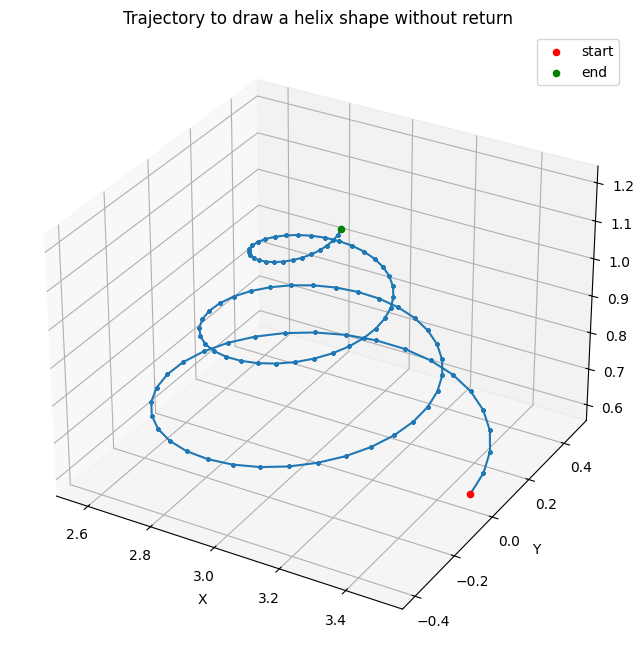

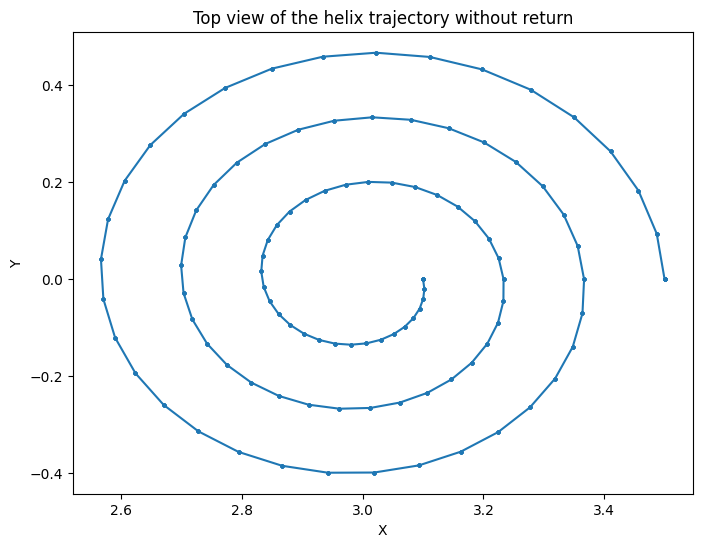

Shape of trajectory: (590, 3)


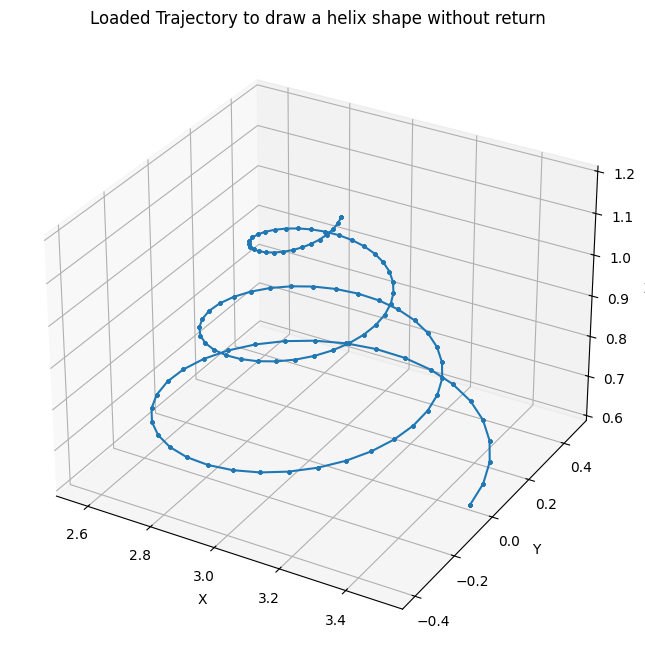

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy import signal
from mpl_toolkits.mplot3d import Axes3D

# Select the shape
shape_type: str = "slalom"  # Options: "slalom", "zigzag", "helix"
tag: str = "_v0"  # Tag to differentiate between different versions

# Option to reverse the trajectory
reverse_trajectory: bool = False  # Set to True to include reverse path, False otherwise

# save trajectory
save_trajectory: bool = True

# Parameter t (more points for smoother/slower trajectory)
num_points = 100
t = np.linspace(0, 4 * np.pi, num_points)  # Adjusted for multiple turns

# x limits
x_min, x_max = 1.0, 5.0

# z limits
z_min, z_max = 0.4, 1.0  # Increased z_max for a taller helix

# Depending on shape_type, define x, y, and z
if shape_type == "slalom":
    # x varies from x_min to x_max
    x = np.linspace(x_min, x_max, num_points)
    # y oscillates
    num_oscillations = 3  # Adjust as desired
    y_amplitude = 0.3  # Adjust amplitude
    y = y_amplitude * np.sin(num_oscillations * t)
    # z varies smoothly
    z = np.linspace(z_min, z_max, num_points)
elif shape_type == "zigzag":
    # x varies from x_min to x_max
    x = np.linspace(x_min, x_max, num_points)
    # y varies as sawtooth function
    num_zigs = 5  # Number of zigs
    y_amplitude = 1.0
    y = y_amplitude * signal.sawtooth(num_zigs * t, 0.5)  # 0.5 gives symmetric triangle wave
    # z varies smoothly
    z = np.linspace(z_min, z_max, num_points)
elif shape_type == "helix":
    # Helix parameters
    helix_radius_start = 0.5  # Starting radius at the base
    helix_radius_end = 0.10   # Ending radius at the top (smaller value)
    helix_turns = 3           # Number of turns
    helix_height = z_max - z_min  # Height of the helix

    # Angle parameter for the helix
    theta = np.linspace(0, helix_turns * 2 * np.pi, num_points)

    # z coordinates increase linearly to create the helical rise
    z = np.linspace(z_min, z_max, num_points)

    # Radius decreases linearly from helix_radius_start to helix_radius_end
    radius = np.linspace(helix_radius_start, helix_radius_end, num_points)

    # x and y coordinates for the conical helix
    x_center = (x_min + x_max) / 2  # Center x position
    y_center = 0.0                  # Center y position

    x = x_center + radius * np.cos(theta)
    y = y_center + radius * np.sin(theta)
else:
    raise ValueError(f"Unknown shape_type: {shape_type}")

# Normalize z to desired range
z_min_current, z_max_current = z.min(), z.max()
z_normalized = (z - z_min_current) / (z_max_current - z_min_current)
z_scaled = z_normalized * (z_max - z_min) + z_min

# For helix, use x and y as they are; for other shapes, normalize if needed
if shape_type != "helix":
    # Normalize y to desired range
    desired_range_y = [-0.3, 0.3]
    y_min, y_max = y.min(), y.max()
    y_normalized = (y - y_min) / (y_max - y_min)
    y_scaled = y_normalized * (desired_range_y[1] - desired_range_y[0]) + desired_range_y[0]

    # Normalize x to desired range
    desired_range_x = [x_min, x_max]
    x_min_current, x_max_current = x.min(), x.max()
    x_normalized = (x - x_min_current) / (x_max_current - x_min_current)
    x_scaled = x_normalized * (desired_range_x[1] - desired_range_x[0]) + desired_range_x[0]
else:
    x_scaled = x
    y_scaled = y

# Repeat first point n times to pause at the start
repeat_first_point_times = 10
x_scaled = np.insert(x_scaled, 0, [x_scaled[0]] * (repeat_first_point_times - 1))
y_scaled = np.insert(y_scaled, 0, [y_scaled[0]] * (repeat_first_point_times - 1))
z_scaled = np.insert(z_scaled, 0, [z_scaled[0]] * (repeat_first_point_times - 1))

# Repeat the last point n times to pause at the end
repeat_last_point_times = 10
x_scaled = np.append(x_scaled, [x_scaled[-1]] * (repeat_last_point_times - 1))
y_scaled = np.append(y_scaled, [y_scaled[-1]] * (repeat_last_point_times - 1))
z_scaled = np.append(z_scaled, [z_scaled[-1]] * (repeat_last_point_times - 1))

# Repeat each point to slow down the trajectory
repeat_times = 5
x_repeated = np.repeat(x_scaled, repeat_times)
y_repeated = np.repeat(y_scaled, repeat_times)
z_repeated = np.repeat(z_scaled, repeat_times)

# Initialize total trajectory with forward path
x_total = x_repeated
y_total = y_repeated
z_total = z_repeated

# Add reverse trajectory if reverse_trajectory is True
if reverse_trajectory:
    # Create reverse trajectory excluding the last point to avoid duplication
    x_back = x_repeated[::-1][1:]
    y_back = y_repeated[::-1][1:]
    z_back = z_repeated[::-1][1:]

    # Concatenate forward and reverse trajectories
    x_total = np.concatenate((x_repeated, x_back))
    y_total = np.concatenate((y_repeated, y_back))
    z_total = np.concatenate((z_repeated, z_back))

# Plot the trajectory in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_total, y_total, z_total, '-o', markersize=2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
title_suffix = "with return" if reverse_trajectory else "without return"
ax.set_title(f'Trajectory to draw a {shape_type} shape {title_suffix}')
ax.scatter(x_total[0], y_total[0], z_total[0], color='red', label='start')
ax.scatter(x_total[-1], y_total[-1], z_total[-1], color='green', label='end')
ax.legend()
plt.show()

# Plot 2D view from top
plt.figure(figsize=(8, 6))
plt.plot(x_total, y_total, '-o', markersize=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Top view of the {shape_type} trajectory {title_suffix}')
plt.show()

if save_trajectory:
    # Save trajectory as array
    trajectory = np.column_stack((x_total, y_total, z_total))
    print("Shape of trajectory:", trajectory.shape)
    with open(f"goal_traj/{shape_type}{tag}_goal_trajectory.pkl", "wb") as f:
        pickle.dump(trajectory, f)

    # Import and plot the trajectory to check
    with open(f"goal_traj/{shape_type}{tag}_goal_trajectory.pkl", "rb") as f:
        trajectory_loaded = pickle.load(f)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(trajectory_loaded[:, 0], trajectory_loaded[:, 1], trajectory_loaded[:, 2], '-o', markersize=2)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Loaded Trajectory to draw a {shape_type} shape {title_suffix}')
    plt.show()

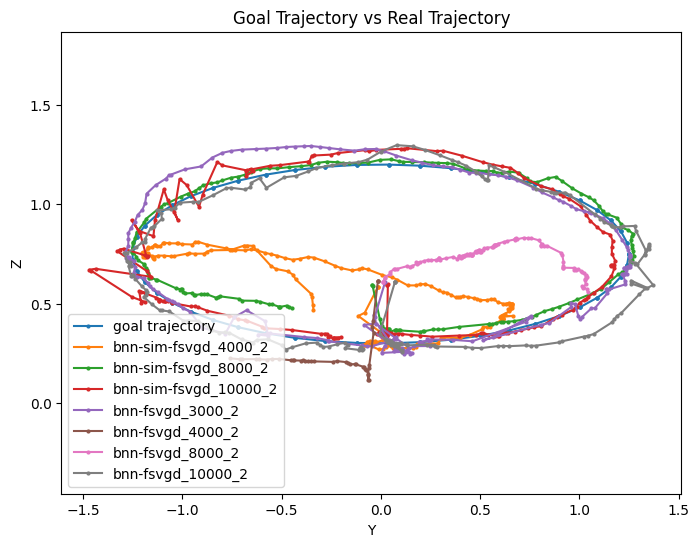

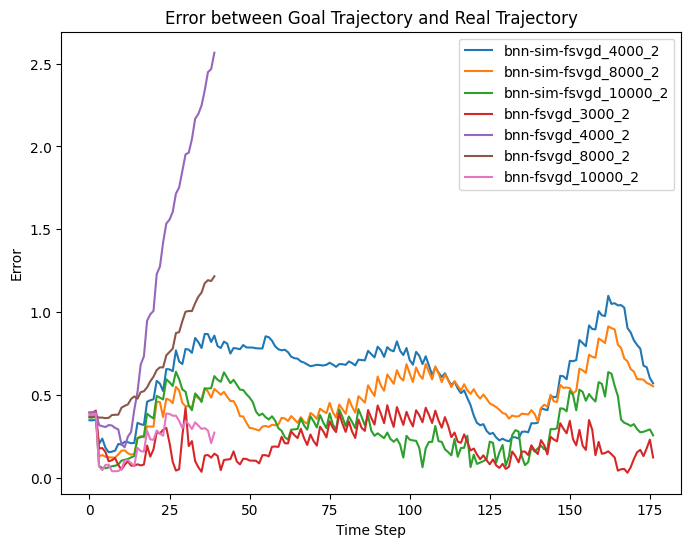

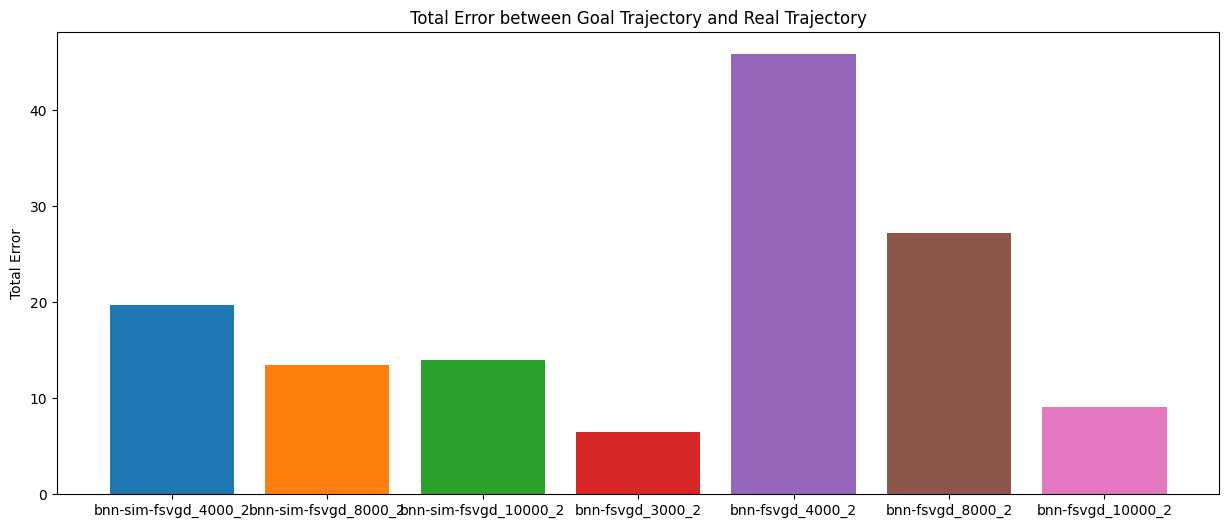

In [14]:
"""Compare simple goal trajectory with real trajectory"""

import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the goal trajectory
file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/goal_traj/ellipse_large_sparse_goal_trajectory.pkl"
with open(file, "rb") as f:
    goal_trajectory = pickle.load(f)

# Load the real trajectory
def import_real_trajectory(file):
    dir_name = file.split("/")[-2]
    dir_name = dir_name.replace('test_shape_tracing_new_data_v15_', '')
    name_parts = dir_name.split('_')
    name = '_'.join(name_parts[:3])
    with open(file, "rb") as f:
        data = pickle.load(f)
    observations_real = np.array([d.observation for d in data])
    return observations_real, name

files = [
    # "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse_new/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_8000_2_ellipse_large_sparse_new_gq2j9xcw_v/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_4000_2_ellipse_large_sparse_qvfrf9ds_v/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_8000_2_ellipse_large_sparse_gq2j9xcw_v/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_10000_2_ellipse_large_sparse_uv3iy3sj_v_v1/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_3000_2_ellipse_large_sparse_uv9xjeet_v_v1/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_4000_2_ellipse_large_sparse_38aum9oe_v/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_8000_2_ellipse_large_sparse_028626c0_v/brax_transitions.pickle",
    "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_10000_2_ellipse_large_sparse_mto6q10t_v/brax_transitions.pickle"
]


# Plot the goal trajectory and the real trajectory in 2D Y-Z plane
plt.figure(figsize=(8, 6))
plt.plot(goal_trajectory[:, 1], goal_trajectory[:, 2], '-o', markersize=2, label='goal trajectory')
for file in files:
    observations_real, name = import_real_trajectory(file)
    plt.plot(observations_real[:, 8], observations_real[:, 9], '-o', markersize=2, label=name)
plt.xlabel('Y')
plt.ylabel('Z')
plt.title('Goal Trajectory vs Real Trajectory')
plt.axis('equal')
plt.legend()
plt.show()

# plot error
plt.figure(figsize=(8, 6))
for file in files:
    x_idx = 7
    y_idx = 8
    z_idx = 9
    observations_real, name = import_real_trajectory(file)
    # make same length if necessary and warn
    if len(observations_real) != len(goal_trajectory):
        print(f"Warning: trajectory lengths are different for {name}")
        min_len = min(len(observations_real), len(goal_trajectory))
        observations_real = observations_real[:min_len]
        goal_trajectory = goal_trajectory[:min_len]
    error = np.linalg.norm(observations_real[:, [x_idx, y_idx, z_idx]] - goal_trajectory, axis=1)
    plt.plot(error, label=name)

plt.xlabel('Time Step')
plt.ylabel('Error')
plt.title('Error between Goal Trajectory and Real Trajectory')
plt.legend()
plt.show()

# plot total error
plt.figure(figsize=(15, 6))
for file in files:
    x_idx = 7
    y_idx = 8
    z_idx = 9
    observations_real, name = import_real_trajectory(file)
    # make same length if necessary and warn
    if len(observations_real) != len(goal_trajectory):
        print(f"Warning: trajectory lengths are different for {name}")
        min_len = min(len(observations_real), len(goal_trajectory))
        observations_real = observations_real[:min_len]
        goal_trajectory = goal_trajectory[:min_len]
    error = np.linalg.norm(observations_real[:, [x_idx, y_idx, z_idx]] - goal_trajectory, axis=1)
    total_error = np.sum(error)
    plt.bar(name, total_error)

plt.ylabel('Total Error')
plt.title('Total Error between Goal Trajectory and Real Trajectory')
plt.show()
